Taavon Peoples QML Project

Data Encoding

In [26]:
# If you have not already, install scikit learn
%pip install scikit-learn
%pip install qiskit
%pip install qiskit-aer --quiet
%pip install pylatexenc
%pip install matplotlib
%pip install qiskit-ibm-runtime
%pip install qiskit-ibm-transpiler

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [11]:
import sys
from pathlib import Path
import importlib

# add project root (current working dir or nearest parent containing utils.py) to sys.path and import utils
cwd = Path.cwd().resolve()
for folder in [cwd] + list(cwd.parents):
    if (folder / "utils.py").is_file():
        sys.path.insert(0, str(folder))
        utils = importlib.import_module("utils")
        break
else:
    raise FileNotFoundError("utils.py not found in project root or any parent directory")

In [28]:
from qiskit_ibm_runtime import QiskitRuntimeService
QiskitRuntimeService.save_account(
     token="yZoR4zRA8X7ZX2rauN_pkmyBrId1CJbbXR1RoN_dFvJh",
     set_as_default = True
     )

AccountAlreadyExistsError: 'Named account (default-ibm-quantum-platform) already exists. Set overwrite=True to overwrite.'

Step 1 Data Encoding
Map inputs to quantum circuit

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
from utils import init

# This only needs to be run once, as the dataset is cached after the first run
dataset = init()

print(dataset["Black"][:20])

circuit depth =  9


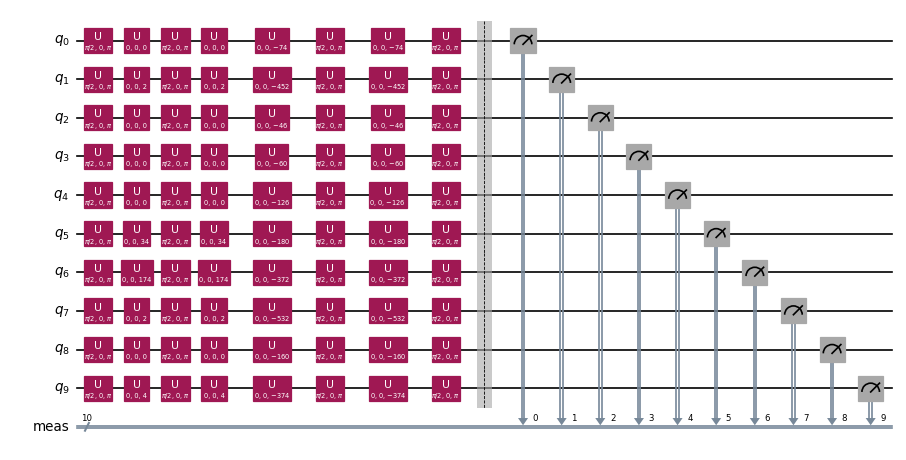

In [23]:
from qiskit.circuit.library import z_feature_map
from qiskit.circuit.library import unitary_overlap

# Data points with labels removed, for inner product
train_data = [dataset["Black"][:10], dataset["White"][:10]]

# Encode the data into quantum states using the ZFeatureMap
fm = z_feature_map(feature_dimension=np.shape(train_data)[1])

#Assign Params
unitary1 = fm.assign_parameters(train_data[0])
unitary2 = fm.assign_parameters(train_data[1])

overlap_circ = unitary_overlap(unitary1, unitary2)
overlap_circ.measure_all()

print("circuit depth = ", overlap_circ.decompose().depth())
overlap_circ.decompose().draw("mpl", scale=0.6, style="iqp")

Step 2
Optimize the circuit for execution

In [30]:
# Import needed packages
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService

# Get the least busy backend
service = QiskitRuntimeService()
backend = service.least_busy(
    # NOTE: Using Simulator for testing, for speed
    operational=True, simulator=False, min_num_qubits=fm.num_qubits
)
print(backend)

qiskit_runtime_service.__init__:WARNING:2026-03-14 10:53:55,340: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open, pay-as-you-go), the available account instances are: open-instance, paid-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-14 10:53:56,737: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-14 10:53:58,306: Loading instance: paid-instance, plan: pay-as-you-go
qiskit_runtime_service.backends:WARNING:2026-03-14 10:54:02,543: Using instance: open-instance, plan: open


<IBMBackend('ibm_torino')>


In [31]:
# Apply level 3 optimization to our overlap circuit
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
overlap_ibm = pm.run(overlap_circ)

print("circuit depth = ", overlap_ibm.decompose().depth())
overlap_ibm.decompose().depth(lambda instr: len(instr.qubits) > 1)

circuit depth =  10


1

Step 3: Execute the circuit

In [32]:
# Run this for a simulator
from qiskit.primitives import StatevectorSampler

from qiskit_ibm_runtime import Options, Session, Sampler

num_shots = 10000

# Evaluate the problem using state vector-based primitives from Qiskit
sampler = StatevectorSampler()
results = sampler.run([overlap_circ], shots=num_shots).result()
# .get_counts() returns counts associated with a state labeled by bit results such as |001101...01>.
counts_bit = results[0].data.meas.get_counts()
# .get_int_counts returns the same counts, but labeled by integer equivalent of the above bit string.
counts = results[0].data.meas.get_int_counts()

The cell below is  for real QC execution. Create methods for this 

In [ ]:
# Benchmarked on an Eagle processor, 7-11-24, took 4 sec.
#this is to execure on a real machine
# Import our runtime primitive
from qiskit_ibm_runtime import Session, SamplerV2 as Sampler

num_shots = 10000

# Use sampler and get the counts

sampler = Sampler(mode=backend)
#this one is using the overlap_ibm circuit instead of overlap_circ
results = sampler.run([overlap_ibm], shots=num_shots).result()
# .get_counts() returns counts associated with a state labeled by bit results such as |001101...01>.
counts_bit = results[0].data.meas.get_counts()
# .get_int_counts returns the same counts, but labeled by integer equivalent of the above bit string.
counts = results[0].data.meas.get_int_counts()

Convert answer back to classical by reading the 0 bit

In [ ]:
counts.get(0, 0.0) / num_shots



0.0

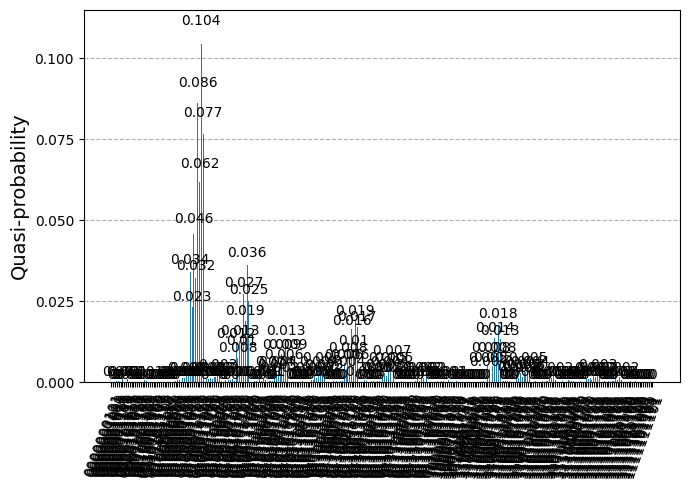

In [36]:
from qiskit.visualization import plot_distribution

plot_distribution(counts_bit)


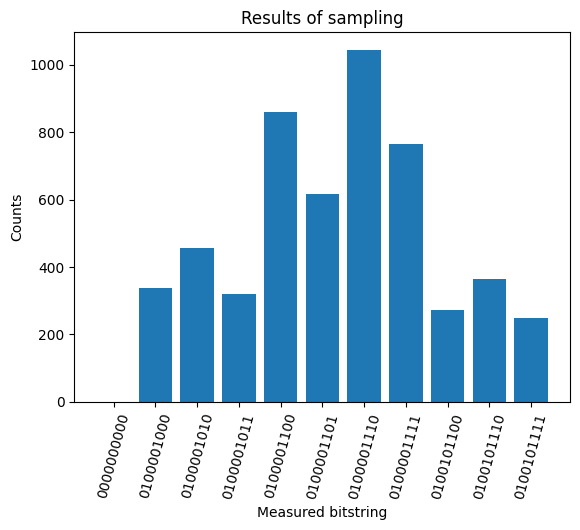

In [37]:
def visualize_counts(probs, num_qubits):
    """Visualize the outputs from the Qiskit Sampler primitive."""
    zero_prob = probs.get(0, 0.0)
    top_10 = dict(sorted(probs.items(), key=lambda item: item[1], reverse=True)[:10])
    top_10.update({0: zero_prob})
    by_key = dict(sorted(top_10.items(), key=lambda item: item[0]))
    xvals, yvals = list(zip(*by_key.items()))
    xvals = [bin(xval)[2:].zfill(num_qubits) for xval in xvals]
    plt.bar(xvals, yvals)
    plt.xticks(rotation=75)
    plt.title("Results of sampling")
    plt.xlabel("Measured bitstring")
    plt.ylabel("Counts")
    plt.show()


visualize_counts(counts, overlap_circ.num_qubits)